# High-Volume-Return-Premium -- do heavily-traded stocks keep climbing?
### Gervais-Kaniel-Mingelgrin (2001): the visibility shock, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

In 2001, Simon Gervais, Ron Kaniel and Dan Mingelgrin published a curious finding: a stock that trades on **unusually high volume** over a day or a week tends to *appreciate* over the next few weeks -- and a stock that trades on unusually **low** volume tends to *lag*. They called it the **high-volume return premium** and explained it as a visibility shock: a heavy-volume day puts the stock on more investors' radar, the investor base widens, and the price drifts up.

We test that exact sort -- rank by abnormal volume, long the loud names, short the quiet ones -- on a basket of large-cap survivors, naming the survivorship bias and the one execution lag up front.

> **This is the plain-language layer.** Want the abnormal-volume construction, the label-shuffle null, and the horizon sweep? See the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from high_volume_return_premium import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "hv_returns.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "hv_volume.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    ret, vol = data.fetch_panel()
    ret = data.drop_partial_last_week(ret); vol = vol.reindex(ret.index)
    ls   = st.long_short(ret, vol, horizon=1, cost_bps=0.0)
    ls_n = st.long_short(ret, vol, horizon=1, cost_bps=5.0, borrow_ann_bps=50.0)
    s_ls   = st.summary(ls["ls_gross"])
    s_net  = st.summary(ls_n["ls_net"])
    s_long = st.summary(ls["long_ret"])
    s_short= st.summary(ls["short_ret"])
    print(f"N weeks: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | one-sample t: {s_ls['t_os']:+.3f}")


yfinance cache present: True


N weeks: 622 | LS mean: -5.47%/yr | one-sample t: -1.343


## The answer first

| Question | Answer |
|---|---|
| Do the loud names out-run the quiet ones? | **No.** The long-short earns **-5.47%/yr** (one-sample *t* = **-1.34**) -- the *wrong* sign for the premium. |
| Is the sort even real? | **No.** A within-week label-shuffle places the real book at **p = 0.12** -- indistinguishable from random labels. |
| Could you trade it? | **No.** Net of costs it loses **-11.2%/yr** on ~64%/week turnover. |
| Survivorship problem? | **Yes, and we name it.** The blow-up names that trade on the biggest volume spikes were deleted from the basket. |

> The premium is documented on old, broad NYSE tapes. On 12 years of 40 mega-cap survivors it is the wrong sign, statistically a coin, and badly negative net.

## 1 -- The claim

> *"Stocks experiencing unusually high (low) trading volume over a day or a week tend to appreciate (depreciate) over the course of the following month. We call this the high-volume return premium ... consistent with ... the trade affecting the stock's visibility."*

-- Gervais, Kaniel & Mingelgrin (2001), *Journal of Finance*

The mechanism leans on Merton (1987): a stock known to more investors carries a higher price. A volume spike is an attention event -- it recruits new holders, and their buying lifts the price over the following weeks. The trade writes itself: buy this week's loud names, sell the quiet ones.

## 2 -- So what?

If true, it is a clean, cheap-to-compute signal: you only need volume, which every feed carries. It would say attention itself is priced at short horizons -- a behavioural anomaly with a tidy economic story. It has spawned a literature on attention and retail trading (Barber-Odean 2008) and cross-country tests (Kaniel-Ozoguz-Starks 2012).

Our questions:
1. **Does it survive on a modern, liquid, much-watched large-cap basket?**
2. **Is the sort distinguishable from random labels?**
3. **What does the survivorship bias do to a volume-spike sort?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Abnormal, not raw, volume.** We divide each week's average daily volume by the stock's own trailing 8-week mean -- a stock is 'high volume' relative to *itself*, computed on strictly past data.
2. **One execution lag.** The signal is known at Friday's close; we trade the **next** week's return. No same-bar fill, no look-ahead.
3. **A label-shuffle placebo.** We permute the volume labels across names within each week and re-run. If the real book is no better than random labels, the sort is noise -- and we say so.

## 4 -- The teardown

**First, does the engine work when the premium is planted?**

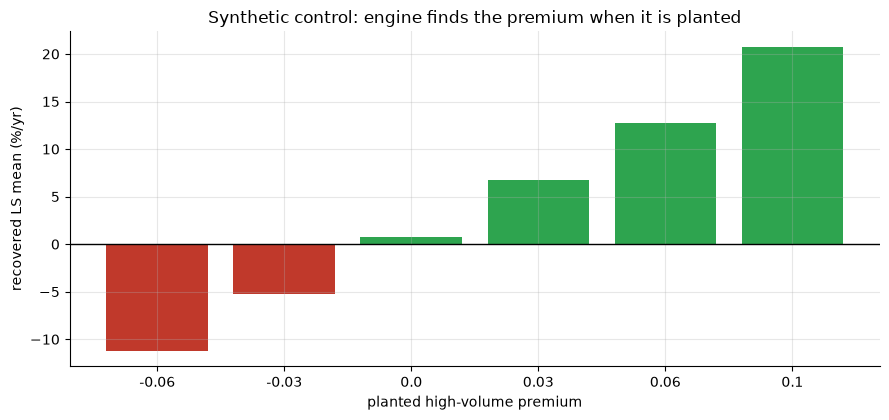

 premium  ls_mean_ann_%   t_os
   -0.06        -11.261 -2.904
   -0.03         -5.254 -1.355
    0.00          0.753  0.194
    0.03          6.760  1.744
    0.06         12.767  3.294
    0.10         20.776  5.361


In [2]:
ctrl = st.sweep_synthetic()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.5 else (RED if m < -0.5 else GREY) for m in ctrl['ls_mean_ann_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['ls_mean_ann_%'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted high-volume premium'); ax.set_ylabel('recovered LS mean (%/yr)')
ax.set_title('Synthetic control: engine finds the premium when it is planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: a planted premium of zero returns a coin (t≈0.2), and the recovered long-short is monotone in the planted premium. So the real-tape verdict reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance panel.**

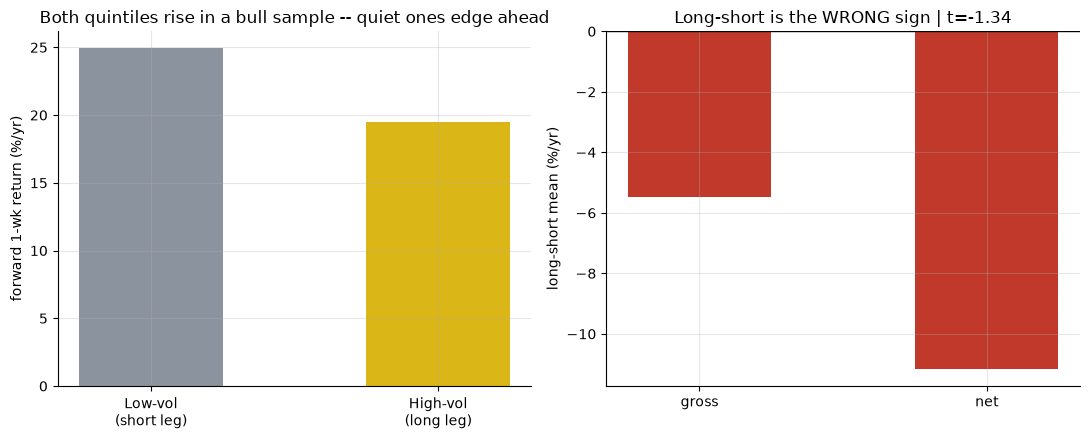

Long-short: -5.47%/yr gross | -11.17%/yr net | t=-1.34


In [3]:
if HAVE_REAL:
    ls_m, ls_t = s_ls['mean']*100, s_ls['t_os']
    lo_m, hi_m = s_short['mean']*100, s_long['mean']*100
    net_m = s_net['mean']*100
else:
    ls_m, ls_t = R['ls_mean'], R['ls_t']
    lo_m, hi_m = R['short_leg'], R['long_leg']
    net_m = R['net_mean']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['Low-vol\n(short leg)', 'High-vol\n(long leg)']
axes[0].bar(labels, [lo_m, hi_m], color=[GREY, AMBER], width=0.5)
axes[0].set_ylabel('forward 1-wk return (%/yr)')
axes[0].set_title('Both quintiles rise in a bull sample -- quiet ones edge ahead')
axes[1].bar(['gross', 'net'], [ls_m, net_m], color=[RED, RED], width=0.5)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('long-short mean (%/yr)')
axes[1].set_title(f'Long-short is the WRONG sign | t={ls_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Long-short: {ls_m:+.2f}%/yr gross | {net_m:+.2f}%/yr net | t={ls_t:+.2f}')

The loud-minus-quiet book earns **-5.47%/yr** at one-sample *t* = **-1.34** -- the wrong sign and well inside |t|<2. Net of costs it is **-11.2%/yr**. There is no high-volume premium to harvest here.

**Is the sort distinguishable from random labels?**

In [4]:
if HAVE_REAL:
    rm = float(ls['ls_gross'].mean())
    pb = st.placebo_pvalue(ret, vol, real_mean=rm, n_shuffles=150, horizon=1)
    p, nm, ns = pb['p'], pb['null_mean']*100, pb['null_std']*100
    real_wk = rm*100
else:
    p, nm, ns, real_wk = R['placebo_p'], R['null_weekly'], R['null_std'], R['real_weekly']
print(f'Placebo p-value: {p:.3f}  (real weekly mean {real_wk:+.4f}% vs '
      f'null {nm:+.4f}% +/- {ns:.4f}%)')
if p > 0.10:
    print('-> the real book is INDISTINGUISHABLE from random labels. None.')
else:
    print('-> the real book beats the shuffled null.')

Placebo p-value: 0.120  (real weekly mean -0.1051% vs null +0.0010% +/- 0.0659%)
-> the real book is INDISTINGUISHABLE from random labels. None.


Placebo **p = 0.12** (and 0.12 / 0.10 / 0.12 across seeds). The sort carries no information that random labels did not.

## 5 -- The verdict

- **Signal -- NONE.** One-sample *t* = -1.34 (wrong sign), placebo p = 0.12. The premium does not replicate on modern large-caps. None, not Weak -- there is no positive effect even to partially support, and the literature describes a far broader, older, less-watched universe.
- **Tradability -- MIRAGE.** Gross Sharpe -0.39, net -11.2%/yr, ~64%/week turnover. Nothing to trade.
- **Survivorship -- Named.** The biggest volume spikes belong to blow-ups and takeovers -- the names deleted from a survivor basket. Results are upper bounds, and the upper bound is already negative.

## 6 -- Could you actually trade it?

No -- on three counts:

1. **Wrong sign.** The book loses money gross (-5.47%/yr) before a cent of cost.
2. **Brutal turnover.** A weekly quintile rebalance churns ~64% of the long basket every week; at 5 bps/leg that compounds into a heavy drag, taking the net to -11.2%/yr.
3. **Capacity & crowding.** Even if it had worked, a one-week-horizon mega-cap signal would be the first thing arbitraged away.

## 7 -- Going further

- **Broader, point-in-time universe.** GKM used the full NYSE cross-section. The premium is documented as strongest where investor-recognition frictions bite -- small and mid-caps, *not* the most-watched mega-caps in our basket (Kaniel-Ozoguz-Starks 2012).
- **Include delisted names.** A point-in-time membership list with failed names would let the natural volume-spike short candidates back in.
- **[Study 330 -- Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: the nearest risk-sort neighbour.
- **[Study 418 -- Money-Flow-Index](../../418-money-flow-index/)**: the nearest volume-indicator neighbour.

*Think the high-volume premium survives net of costs on a point-in-time universe with delisted names? Fork this, widen to small/mid-caps, and show t > 2 net. That is the bar.*